In [1]:
# =========================
# TF2 PINN (Jupyter)
# =========================
import numpy as np
import time
import pickle
import scipy.io
import scipy.optimize
import matplotlib.pyplot as plt
#from pyDOE import lhs

import tensorflow as tf
tf.random.set_seed(1234)
np.random.seed(1234)


/opt/anaconda3/envs/tf2/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
import numpy as np

def lhs(n_dim, n_samples, seed=None):
    """
    Latin Hypercube Sampling in [0,1]^n_dim.
    Returns array of shape (n_samples, n_dim).
    """
    rng = np.random.default_rng(seed)

    # Divide [0,1] into n_samples strata
    cut = np.linspace(0.0, 1.0, n_samples + 1)

    # Sample uniformly inside each stratum for each dimension
    u = rng.random((n_samples, n_dim))
    a = cut[:n_samples]
    b = cut[1:n_samples + 1]
    rdpoints = a[:, None] + (b - a)[:, None] * u  # (n_samples, n_dim)

    # Permute strata per dimension
    H = np.empty_like(rdpoints)
    for j in range(n_dim):
        order = rng.permutation(n_samples)
        H[:, j] = rdpoints[order, j]
    return H


In [3]:
# Helpers
    
def DelObsPT(XY, xc, yc, r, xb0, xb1, yb0, yb1):
    """Delete points inside (cylinder) OR inside (beam rectangle)."""
    # cylinder mask
    dst = np.sqrt((XY[:,0]-xc)**2 + (XY[:,1]-yc)**2)
    in_cyl = (dst <= r)

    # beam rectangle mask
    in_beam = (XY[:,0] >= xb0) & (XY[:,0] <= xb1) & (XY[:,1] >= yb0) & (XY[:,1] <= yb1)

    return XY[~(in_cyl | in_beam), :]

def preprocess_mat(dir_path):
    """Load reference solution from Fenics or Fluent mat file.
       Expects keys: x,y,p,vx,vy"""
    data = scipy.io.loadmat(dir_path)
    X = data['x']; Y = data['y']
    P = data['p']
    vx = data['vx']; vy = data['vy']
    return (X.flatten()[:,None], Y.flatten()[:,None],
            vx.flatten()[:,None], vy.flatten()[:,None],
            P.flatten()[:,None])

def postProcess(xmin, xmax, ymin, ymax, field_ref, field_pinn, s=2, alpha=0.5, marker='o'):
    """Same plotting style as your original code."""
    x_ref, y_ref, u_ref, v_ref, p_ref = field_ref
    x_p, y_p, u_p, v_p, p_p = field_pinn

    fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(7, 4))
    fig.subplots_adjust(hspace=0.2, wspace=0.2)

    def _scatter(axh, x, y, c, title, vmin=None, vmax=None):
        cf = axh.scatter(x, y, c=c, alpha=alpha, edgecolors='none',
                         cmap='rainbow', marker=marker, s=int(s),
                         vmin=vmin, vmax=vmax)
        axh.axis('square')
        for key, spine in axh.spines.items():
            spine.set_visible(False)
        axh.set_xticks([]); axh.set_yticks([])
        axh.set_xlim([xmin, xmax]); axh.set_ylim([ymin, ymax])
        axh.set_title(title)
        fig.colorbar(cf, ax=axh, fraction=0.046, pad=0.04)

    _scatter(ax[0,0], x_p, y_p, u_p, r'$u$ (PINN)')
    _scatter(ax[1,0], x_p, y_p, v_p, r'$v$ (PINN)')
    _scatter(ax[2,0], x_p, y_p, p_p, r'$p$ (PINN)', vmin=-0.25, vmax=4.0)

    _scatter(ax[0,1], x_ref, y_ref, u_ref, r'$u$ (REF)')
    _scatter(ax[1,1], x_ref, y_ref, v_ref, r'$v$ (REF)')
    _scatter(ax[2,1], x_ref, y_ref, p_ref, r'$p$ (REF)', vmin=-0.25, vmax=4.0)

    plt.show()

# -------------------------
# Keras network
# -------------------------
class MLP(tf.keras.Model):
    def __init__(self, layers_sizes, activation="tanh"):
        super().__init__()
        self.hidden = []
        for w in layers_sizes[:-1]:
            self.hidden.append(tf.keras.layers.Dense(
                w, activation=activation,
                kernel_initializer="glorot_normal"
            ))
        self.out = tf.keras.layers.Dense(
            layers_sizes[-1], activation=None,
            kernel_initializer="glorot_normal"
        )

    def call(self, x, training=False):
        z = x
        for lyr in self.hidden:
            z = lyr(z)
        return self.out(z)

# -------------------------
# Mixed-form PINN in TF2
# -------------------------
class PINN_laminar_flow_TF2:
    """
    TF2 rewrite of your TF1 class:
    Outputs: psi, p, s11, s22, s12
    u = dpsi/dy
    v = -dpsi/dx
    """
    def __init__(self, Collo, INLET, OUTLET, WALL, uv_layers, lb, ub,
                 rho=1000, mu=1, bc_weight=2.0):

        self.lb = lb.astype(np.float32).reshape(1,2)
        self.ub = ub.astype(np.float32).reshape(1,2)

        self.rho = tf.constant(rho, dtype=tf.float32)
        self.mu  = tf.constant(mu, dtype=tf.float32)
        self.bc_weight = tf.constant(bc_weight, dtype=tf.float32)

        # Data
        self.Collo = Collo.astype(np.float32)
        self.INLET = INLET.astype(np.float32)   # [x,y,u,v]
        self.OUTLET = OUTLET.astype(np.float32) # [x,y]
        self.WALL = WALL.astype(np.float32)     # [x,y]

        # Model
        hidden_widths = uv_layers[1:-1]
        out_dim = uv_layers[-1]  # 5
        self.net = MLP(hidden_widths + [out_dim], activation="tanh")

        self.loss_rec = []

    # --- forward outputs (psi,p,s11,s22,s12) ---
    def net_psips(self, x, y):
        xy = tf.concat([x, y], axis=1)
        out = self.net(xy)
        psi = out[:,0:1]
        p   = out[:,1:2]
        s11 = out[:,2:3]
        s22 = out[:,3:4]
        s12 = out[:,4:5]
        return psi, p, s11, s22, s12

    # --- compute u,v and first derivatives with a tape ---
    def uv_and_grads(self, x, y):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y])
            psi, p, s11, s22, s12 = self.net_psips(x, y)
            u = tape.gradient(psi, y)
            v = -tape.gradient(psi, x)

        u_x = tape.gradient(u, x)
        u_y = tape.gradient(u, y)
        v_x = tape.gradient(v, x)
        v_y = tape.gradient(v, y)

        s11_x = tape.gradient(s11, x)
        s12_x = tape.gradient(s12, x)
        s12_y = tape.gradient(s12, y)
        s22_y = tape.gradient(s22, y)

        del tape
        return u, v, p, s11, s22, s12, u_x, u_y, v_x, v_y, s11_x, s12_x, s12_y, s22_y

    # --- PDE residuals (same as your net_f) ---
    def residuals(self, x, y):
        rho = self.rho
        mu  = self.mu

        (u, v, p, s11, s22, s12,
         u_x, u_y, v_x, v_y,
         s11_x, s12_x, s12_y, s22_y) = self.uv_and_grads(x, y)

        f_u = (u*u_x + v*u_y) - s11_x/rho - s12_y/rho
        f_v = (u*v_x + v*v_y) - s12_x/rho - s22_y/rho

        f_s11 = -p + 2.0*mu*u_x - s11
        f_s22 = -p + 2.0*mu*v_y - s22
        f_s12 = mu*(u_y + v_x) - s12

        f_p = p + 0.5*(s11 + s22)
        return f_u, f_v, f_s11, f_s22, f_s12, f_p

    # --- loss ---
    def loss_fn(self, Xc, WALL, INLET, OUTLET):
        # Collocation residuals
        xc = Xc[:,0:1]; yc = Xc[:,1:2]
        fu, fv, fs11, fs22, fs12, fp = self.residuals(xc, yc)
        loss_f = (tf.reduce_mean(tf.square(fu)) +
                  tf.reduce_mean(tf.square(fv)) +
                  tf.reduce_mean(tf.square(fs11)) +
                  tf.reduce_mean(tf.square(fs22)) +
                  tf.reduce_mean(tf.square(fs12)) +
                  tf.reduce_mean(tf.square(fp)))

        # WALL: u=v=0
        xw = WALL[:,0:1]; yw = WALL[:,1:2]
        u_w, v_w, *_ = self.uv_and_grads(xw, yw)
        loss_wall = tf.reduce_mean(tf.square(u_w)) + tf.reduce_mean(tf.square(v_w))

        # INLET: match prescribed u,v
        xi = INLET[:,0:1]; yi = INLET[:,1:2]
        ui = INLET[:,2:3]; vi = INLET[:,3:4]
        u_i, v_i, *_ = self.uv_and_grads(xi, yi)
        loss_in = tf.reduce_mean(tf.square(u_i - ui)) + tf.reduce_mean(tf.square(v_i - vi))

        # OUTLET: gauge pressure condition
        xo = OUTLET[:,0:1]; yo = OUTLET[:,1:2]
        _, p_o, _, _, _ = self.net_psips(xo, yo)

        # More stable than forcing p=0 pointwise:
        loss_out = tf.square(tf.reduce_mean(p_o))

        total = loss_f + self.bc_weight*(loss_wall + loss_in + loss_out)
        return total, loss_f, loss_wall, loss_in, loss_out

    # --- Adam training loop ---
    def train_adam(self, iters=10000, lr=5e-4, print_every=10):
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

        Xc = tf.convert_to_tensor(self.Collo, dtype=tf.float32)
        WALL = tf.convert_to_tensor(self.WALL, dtype=tf.float32)
        INLET = tf.convert_to_tensor(self.INLET, dtype=tf.float32)
        OUTLET = tf.convert_to_tensor(self.OUTLET, dtype=tf.float32)

        for it in range(iters):
            with tf.GradientTape() as tape:
                loss, lf, lw, lin, lout = self.loss_fn(Xc, WALL, INLET, OUTLET)
            grads = tape.gradient(loss, self.net.trainable_variables)
            opt.apply_gradients(zip(grads, self.net.trainable_variables))

            if it % print_every == 0:
                print(f"It {it:6d} | loss={loss.numpy():.3e} "
                      f"| f={lf.numpy():.3e} wall={lw.numpy():.3e} "
                      f"in={lin.numpy():.3e} out={lout.numpy():.3e}")
                self.loss_total = []
                self.loss_pde = []
                self.loss_wall = []
                self.loss_inlet = []
                self.loss_outlet = []           
            #self.loss_rec.append(float(loss.numpy()))
            self.loss_total.append(float(loss.numpy()))
            self.loss_pde.append(float(lf.numpy()))
            self.loss_wall.append(float(lw.numpy()))
            self.loss_inlet.append(float(lin.numpy()))
            self.loss_outlet.append(float(lout.numpy()))

    # --- L-BFGS with SciPy ---
    def train_lbfgs(self, maxiter=50000, maxcor=50):
        Xc = tf.convert_to_tensor(self.Collo, dtype=tf.float32)
        WALL = tf.convert_to_tensor(self.WALL, dtype=tf.float32)
        INLET = tf.convert_to_tensor(self.INLET, dtype=tf.float32)
        OUTLET = tf.convert_to_tensor(self.OUTLET, dtype=tf.float32)

        # pack/unpack weights
        def pack():
            return np.concatenate([v.numpy().reshape(-1) for v in self.net.trainable_variables]).astype(np.float64)

        def unpack(flat):
            idx = 0
            for v in self.net.trainable_variables:
                shape = v.shape
                size = int(np.prod(shape))
                v.assign(flat[idx:idx+size].reshape(shape).astype(np.float32))
                idx += size

        def loss_and_grad(flat):
            unpack(flat)
            with tf.GradientTape() as tape:
                loss, *_ = self.loss_fn(Xc, WALL, INLET, OUTLET)
            grads = tape.gradient(loss, self.net.trainable_variables)
            grad_flat = np.concatenate([g.numpy().reshape(-1) for g in grads]).astype(np.float64)
            return float(loss.numpy()), grad_flat

        x0 = pack()

        def callback(xk):
            l, _ = loss_and_grad(xk)
            total, lf, lw, lin, lout = self.loss_fn(Xc, WALL, INLET, OUTLET)
        
            self.loss_total.append(float(total.numpy()))
            self.loss_pde.append(float(lf.numpy()))
            self.loss_wall.append(float(lw.numpy()))
            self.loss_inlet.append(float(lin.numpy()))
            self.loss_outlet.append(float(lout.numpy()))
        
            print("L-BFGS loss:", l)
    
        res = scipy.optimize.minimize(
            fun=lambda w: loss_and_grad(w),
            x0=x0,
            jac=True,
            method="L-BFGS-B",
            callback=callback,
            options={"maxiter": maxiter, "maxcor": maxcor, "ftol": np.finfo(float).eps}
        )
        unpack(res.x)
        return res

    # --- Save/Load (TF2 style) ---
    def save(self, path="uvNN_tf2"):
        self.net.save_weights(path)

    def load(self, path="uvNN_tf2"):
        # build once
        dummy = tf.zeros((1,2), dtype=tf.float32)
        _ = self.net(dummy)
        self.net.load_weights(path)

    # --- predict u,v,p (and optionally stress) ---

    def predict(self, x_star, y_star):
        x = tf.convert_to_tensor(x_star.astype(np.float32))
        y = tf.convert_to_tensor(y_star.astype(np.float32))
    
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y])
            psi, p, _, _, _ = self.net_psips(x, y)
    
        u = tape.gradient(psi, y)
        v = -tape.gradient(psi, x)
        del tape
    
        return u.numpy(), v.numpy(), p.numpy()

    def predict_all(self, x_star, y_star):
        x = tf.convert_to_tensor(x_star.astype(np.float32))
        y = tf.convert_to_tensor(y_star.astype(np.float32))
    
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y])
            psi, p, s11, s22, s12 = self.net_psips(x, y)
    
        u = tape.gradient(psi, y)
        v = -tape.gradient(psi, x)
        del tape
    
        return u.numpy(), v.numpy(), p.numpy(), s11.numpy(), s22.numpy(), s12.numpy()


Collo shape: (7342, 2)


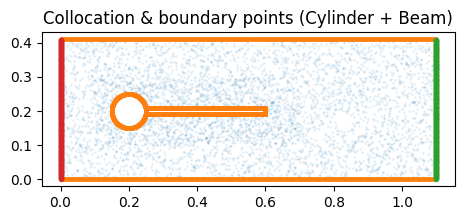

In [4]:
# ---- Benchmark geometry (Turek & Hron 2006) ----
L, H = 1.1, 0.41
lb = np.array([0.0, 0.0])
ub = np.array([L,   H])

# Cylinder
xc, yc, r = 0.2, 0.2, 0.05
d = 2*r

# Beam (rigid bar) from paper:
# length l=0.35, height h=0.02, right-bottom corner (0.6,0.19)
l_beam, h_beam = 0.35, 0.02
x_right, y_bot = 0.6, 0.19
x_left  = x_right - l_beam          # 0.25
y_top   = y_bot + h_beam            # 0.21

# ---- Fluid properties (paper) ----
rho = 1
nu  = 2*1e-2
mu  = rho * nu   # 1.0

# ---- Choose CFD case ----
Ubar = 0.2   # CFD1=0.2, CFD2=1.0, CFD3=2.0
U_max = 1.5 * Ubar   # mean = (2/3) Umax => Umax=1.5 Ubar

# WALL (top/bottom channel)
Nw = 441
wall_up = np.hstack([L*lhs(1, Nw), H*np.ones((Nw,1))])
wall_lw = np.hstack([L*lhs(1, Nw), 0.0*np.ones((Nw,1))])

# INLET (x=0, parabolic)
Ni = 201
y_in = H*lhs(1, Ni)
x_in = np.zeros((Ni,1))
u_in = 4*U_max*y_in*(H-y_in)/(H**2)
v_in = np.zeros_like(u_in)
INLET = np.hstack([x_in, y_in, u_in, v_in])

# OUTLET (x=L)
No = 201
OUTLET = np.hstack([L*np.ones((No,1)), H*lhs(1, No)])

# Cylinder boundary points
Nc = 400
theta = 2*np.pi*lhs(1, Nc)
CYLD = np.hstack([xc + r*np.cos(theta), yc + r*np.sin(theta)])

# Beam boundary points (EXPOSED EDGES ONLY: top, bottom, right)
Nb = 300
# top edge y=y_top, x in [x_left, x_right]
beam_top = np.hstack([x_left + (x_right-x_left)*lhs(1, Nb), y_top*np.ones((Nb,1))])
# bottom edge y=y_bot
beam_bot = np.hstack([x_left + (x_right-x_left)*lhs(1, Nb), y_bot*np.ones((Nb,1))])
# right edge x=x_right, y in [y_bot, y_top]
beam_right = np.hstack([x_right*np.ones((Nb,1)), y_bot + (y_top-y_bot)*lhs(1, Nb)])

BEAM = np.vstack([beam_top, beam_bot, beam_right])

# Collect all no-slip boundaries into WALL
WALL = np.vstack([CYLD, BEAM, wall_up, wall_lw])

# ---- Collocation points ----
XY_c = lb + (ub - lb) * lhs(2, 4000)
XY_c_refine = np.array([0.1, 0.1]) + np.array([0.6, 0.2]) * lhs(2, 1000)
XY_c = np.vstack([XY_c, XY_c_refine])

# delete obstacle interior (cyl + beam)
XY_c = DelObsPT(XY_c, xc=xc, yc=yc, r=r,
                xb0=x_left, xb1=x_right, yb0=y_bot, yb1=y_top)

# include boundary points in collocation set
XY_c = np.vstack([XY_c, WALL, OUTLET, INLET[:,0:2]])
print("Collo shape:", XY_c.shape)

# Visualize points
fig, ax = plt.subplots(figsize=(10, 2))
ax.set_aspect('equal')
plt.scatter(XY_c[:,0], XY_c[:,1], s=1, alpha=0.08)
plt.scatter(WALL[:,0], WALL[:,1], s=6, alpha=0.6)
plt.scatter(OUTLET[:,0], OUTLET[:,1], s=10, alpha=0.6)
plt.scatter(INLET[:,0], INLET[:,1], s=10, alpha=0.6)
plt.title("Collocation & boundary points (Cylinder + Beam)")
plt.show()

In [5]:
# Network configuration 
uv_layers = [2] + 8*[40] + [5]
# 4*[64/128/xx]
# beam
# multiply freq

model = PINN_laminar_flow_TF2(
    XY_c, INLET, OUTLET, WALL, uv_layers, lb, ub,
    rho=rho, mu=mu, bc_weight=10
)

start = time.time()
model.train_adam(iters=10000, lr=5e-4, print_every=10)
res = model.train_lbfgs(maxiter=50000)
print("Elapsed (s):", time.time() - start)

2026-02-21 21:02:33.599239: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-02-21 21:02:33.599259: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-21 21:02:33.599265: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-21 21:02:33.599281: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-21 21:02:33.599290: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


It      0 | loss=8.407e-01 | f=9.166e-02 wall=2.078e-03 in=4.322e-02 out=2.960e-02
It     10 | loss=3.087e-01 | f=1.351e-02 wall=6.084e-03 in=2.335e-02 out=8.560e-05
It     20 | loss=2.860e-01 | f=1.422e-02 wall=1.399e-02 in=1.313e-02 out=5.651e-05
It     30 | loss=2.566e-01 | f=2.092e-03 wall=8.182e-03 in=1.722e-02 out=4.101e-05
It     40 | loss=2.453e-01 | f=1.606e-03 wall=8.677e-03 in=1.565e-02 out=3.912e-05
It     50 | loss=2.308e-01 | f=1.074e-03 wall=9.182e-03 in=1.378e-02 out=1.590e-05
It     60 | loss=2.140e-01 | f=1.024e-03 wall=7.366e-03 in=1.393e-02 out=3.333e-06
It     70 | loss=2.008e-01 | f=1.131e-03 wall=6.922e-03 in=1.304e-02 out=7.013e-06
It     80 | loss=1.925e-01 | f=1.281e-03 wall=6.655e-03 in=1.247e-02 out=8.235e-07
It     90 | loss=1.855e-01 | f=1.202e-03 wall=6.278e-03 in=1.215e-02 out=2.045e-06
It    100 | loss=1.800e-01 | f=1.096e-03 wall=6.049e-03 in=1.184e-02 out=6.794e-07
It    110 | loss=1.746e-01 | f=1.035e-03 wall=5.995e-03 in=1.137e-02 out=2.251e-07
It  

In [6]:
# Save weights
model.save("uvNN_tf2_weights_beam1_weight10.weights.h5")

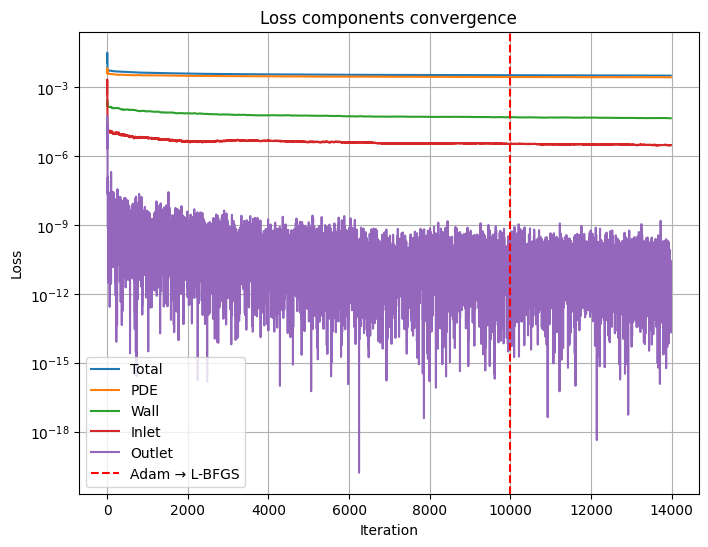

In [14]:
loss = np.array(model.loss_rec)

adam_iters = 10000  # number of Adam iterations

plt.figure(figsize=(8,6))

plt.semilogy(model.loss_total, label="Total")
plt.semilogy(model.loss_pde, label="PDE")
plt.semilogy(model.loss_wall, label="Wall")
plt.semilogy(model.loss_inlet, label="Inlet")
plt.semilogy(model.loss_outlet, label="Outlet")
plt.axvline(adam_iters, color='r', ls='--', lw=1.5, label="Adam → L-BFGS")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss components convergence")
plt.grid(True)
plt.show()

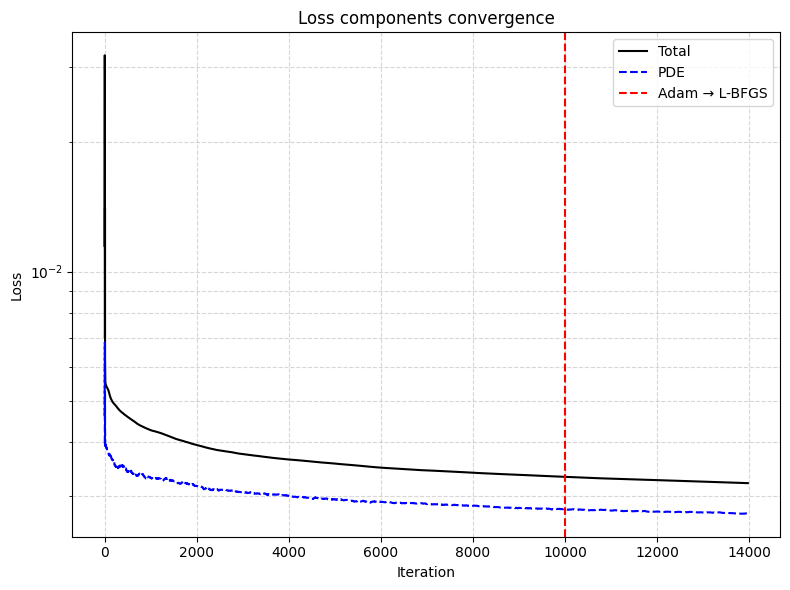

In [20]:
adam_iters = 10000  # number of Adam iterations

plt.figure(figsize=(8,6))

plt.semilogy(model.loss_total, 'k-', label="Total")
plt.semilogy(model.loss_pde, 'b--', label="PDE")
plt.axvline(adam_iters, color='r', ls='--', lw=1.5, label="Adam → L-BFGS")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss components convergence")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

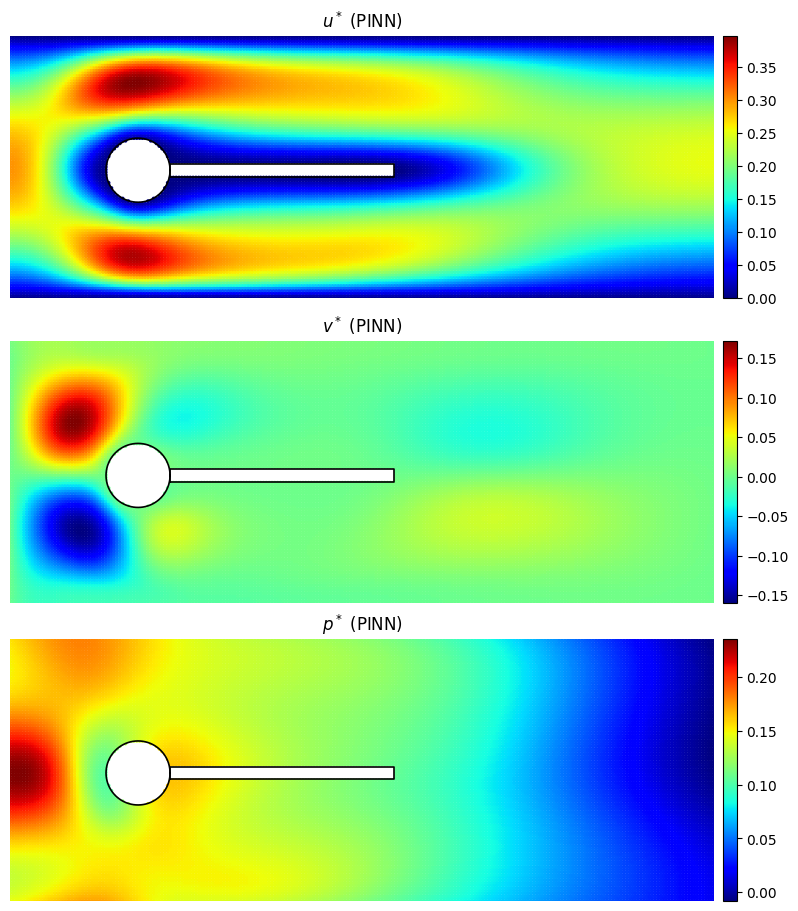

In [13]:
# =========================
# Complete plotting code: show u*, v*, p* with cylinder + beam visible
# (assumes you already trained model and have model.predict working)
# =========================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Geometry (Turek–Hron style; edit beam_L / beam_t if your PDF differs)
# -------------------------
L, H = 1.1, 0.41
xc, yc, r = 0.2, 0.2, 0.05

beam_L = 0.35      # beam length (attached behind cylinder)
beam_t = 0.02      # beam thickness
beam_x0 = xc + r
beam_x1 = beam_x0 + beam_L
beam_y0 = yc - beam_t/2
beam_y1 = yc + beam_t/2

# -------------------------
# Build evaluation grid (fluid field points)
# -------------------------
nx, ny = 251, 101
xg = np.linspace(0.0, L, nx)
yg = np.linspace(0.0, H, ny)
Xg, Yg = np.meshgrid(xg, yg)

x_star = Xg.reshape(-1, 1)
y_star = Yg.reshape(-1, 1)

# Mask out cylinder interior
dst_cyl = np.sqrt((x_star - xc)**2 + (y_star - yc)**2)
mask_cyl = (dst_cyl[:, 0] >= r)

# Mask out beam interior (rectangle)
mask_beam = ~(
    (x_star[:, 0] >= beam_x0) & (x_star[:, 0] <= beam_x1) &
    (y_star[:, 0] >= beam_y0) & (y_star[:, 0] <= beam_y1)
)

mask = mask_cyl & mask_beam

x_eval = x_star[mask]
y_eval = y_star[mask]

# -------------------------
# PINN prediction
# -------------------------
# IMPORTANT: model.predict expects (N,1) arrays.
u_p, v_p, p_p = model.predict(x_eval, y_eval)

# Ensure 1D arrays for scatter colors
u_p = np.asarray(u_p).reshape(-1)
v_p = np.asarray(v_p).reshape(-1)
p_p = np.asarray(p_p).reshape(-1)

# -------------------------
# Solid outlines (cylinder + beam)
# -------------------------
theta = np.linspace(0, 2*np.pi, 400)
cyl_x = xc + r*np.cos(theta)
cyl_y = yc + r*np.sin(theta)

beam_poly_x = [beam_x0, beam_x1, beam_x1, beam_x0, beam_x0]
beam_poly_y = [beam_y0, beam_y0, beam_y1, beam_y1, beam_y0]

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(3, 1, figsize=(10, 9), constrained_layout=True)

def scatter_field(axh, x, y, c, title):
    sc = axh.scatter(x, y, c=c, s=3, cmap="jet")
    axh.set_aspect("equal")
    axh.set_title(title)
    axh.set_xlim(0, L)
    axh.set_ylim(0, H)
    axh.axis("off")

    # draw solids
    axh.plot(cyl_x, cyl_y, "k-", lw=1.2)
    axh.plot(beam_poly_x, beam_poly_y, "k-", lw=1.2)

    plt.colorbar(sc, ax=axh, fraction=0.03, pad=0.01)

scatter_field(ax[0], x_eval[:, 0], y_eval[:, 0], u_p, r"$u^*$ (PINN)")
scatter_field(ax[1], x_eval[:, 0], y_eval[:, 0], v_p, r"$v^*$ (PINN)")
scatter_field(ax[2], x_eval[:, 0], y_eval[:, 0], p_p, r"$p^*$ (PINN)")

plt.show()


/var/folders/qq/0y83lt2x4z78hjpkv8jj_yh00000gn/T/ipykernel_68805/1536863416.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


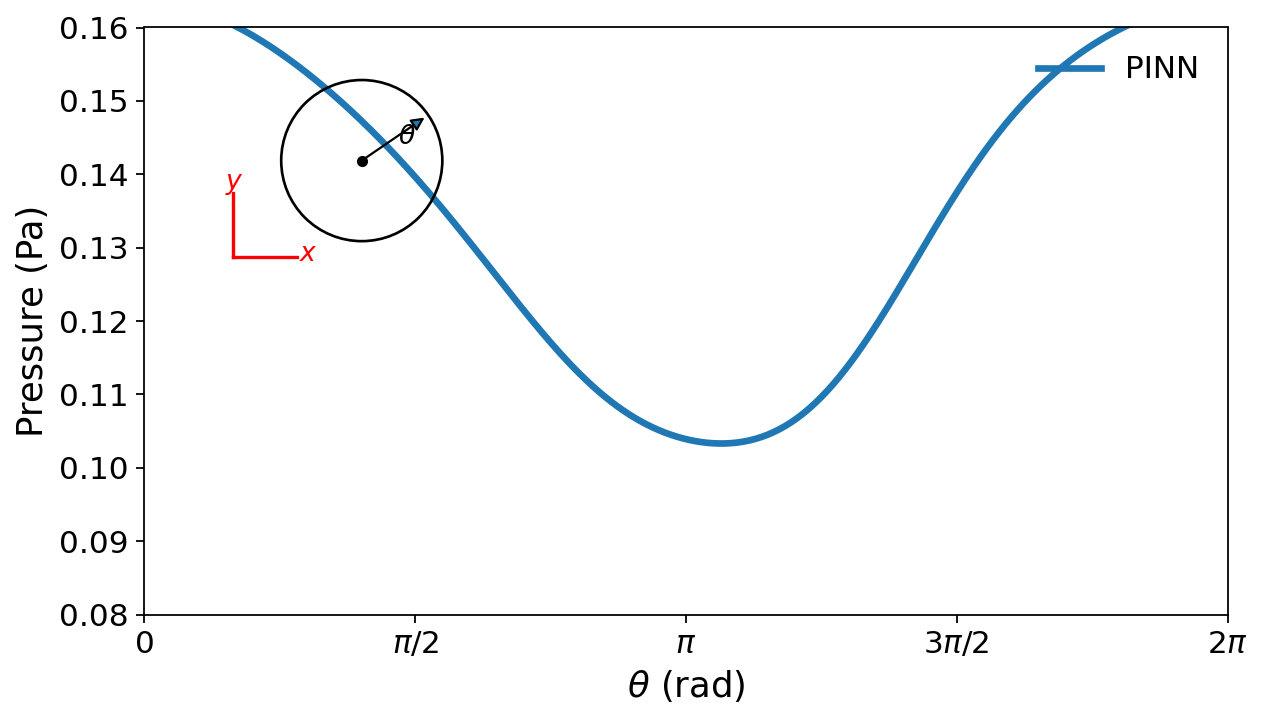

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.patches import Circle, FancyArrowPatch

def pressure_on_cylinder(theta, xc, yc, r, p_func=None, ref_data=None, method="linear"):
    x = xc + r*np.cos(theta)
    y = yc + r*np.sin(theta)

    if p_func is not None:
        p = p_func(x[:, None], y[:, None]).reshape(-1)
        return p

    if ref_data is not None:
        x_ref, y_ref, p_ref = ref_data
        pts_ref = np.hstack([x_ref.reshape(-1,1), y_ref.reshape(-1,1)])
        pts_q   = np.hstack([x.reshape(-1,1),     y.reshape(-1,1)])
        p = griddata(pts_ref, p_ref.reshape(-1), pts_q, method=method)

        # fill NaNs if any
        if np.any(np.isnan(p)):
            p2 = griddata(pts_ref, p_ref.reshape(-1), pts_q, method="nearest")
            p = np.where(np.isnan(p), p2, p)

        return p.reshape(-1)

    raise ValueError("Provide either p_func or ref_data.")

def plot_pressure_distribution(theta, p_pred, ylim=(-0.5, 0.40)):
    fig, ax = plt.subplots(figsize=(8,4.6), dpi=160)

    ax.plot(theta, p_pred, lw=3.0, label="PINN")   # <- your p_pred

    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r'$\theta$ (rad)', fontsize=16)
    ax.set_ylabel('Pressure (Pa)', fontsize=16)

    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax.legend(frameon=False, fontsize=14, loc="upper right")

    # inset sketch (cylinder + theta arrow + x/y axes)
    ax_in = fig.add_axes([0.18, 0.62, 0.18, 0.28])
    ax_in.set_aspect('equal')
    ax_in.axis('off')

    ax_in.add_patch(Circle((0,0), 1.0, fill=False, lw=1.2))
    ax_in.plot([0],[0],'ko', ms=4)

    th0 = 0.6
    ax_in.add_patch(FancyArrowPatch((0,0), (np.cos(th0), np.sin(th0)),
                                    arrowstyle='-|>', mutation_scale=12, lw=1.0))
    ax_in.text(0.45, 0.2, r'$\theta$', fontsize=12)

    ax_in.plot([-1.6, -0.8], [-1.2, -1.2], color='red', lw=1.5)
    ax_in.plot([-1.6, -1.6], [-1.2, -0.4], color='red', lw=1.5)
    ax_in.text(-0.78, -1.25, r'$x$', color='red', fontsize=12)
    ax_in.text(-1.7, -0.35, r'$y$', color='red', fontsize=12)

    plt.tight_layout()
    plt.show()

# ----------------------------
# Usage with your model + reference
# ----------------------------
xc, yc, r = 0.2, 0.2, 0.05
theta = np.linspace(0, 2*np.pi, 361)

# p_pred from PINN (mixed)
p_pred = pressure_on_cylinder(
    theta, xc, yc, r,
    p_func=lambda x, y: model.predict(x, y)[2]   # model.predict returns (u,v,p)
)

# reference (from preprocess_mat)
# x_ref, y_ref, u_ref, v_ref, p_ref = preprocess_mat("FluentSol.mat")

plot_pressure_distribution(theta, p_pred, ylim=(0.08, 0.16))


In [12]:
results = {
    "loss_history": model.loss_total,
    "loss_pde_history": model.loss_pde,
    "loss_wall_history": model.loss_wall,
    "loss_inlet_history": model.loss_inlet,
    "loss_outlet_history": model.loss_outlet,
    "theta": theta,
    "u_pred": u_p,
    "v_pred": v_p,
    "p_pred": p_p,
    "meta": {
        "rho": 1000,
        "mu": 1,
        "layers": uv_layers,
        "bc_weight": 2.0,
        "description": "2D cylinder laminar flow, mixed PINN"
    }
}

with open("pinn_cylinder_beam1_results_weight10.pkl", "wb") as f:
    pickle.dump(results, f)


In [11]:
import numpy as np

def _traction_from_ps(model, x, y, nx, ny):
    """
    Traction t = σ n where σ components are directly predicted:
      σ = [[s11, s12],
           [s12, s22]]
    """
    x = np.asarray(x).reshape(-1, 1).astype(np.float32)
    y = np.asarray(y).reshape(-1, 1).astype(np.float32)
    nx = np.asarray(nx).reshape(-1)
    ny = np.asarray(ny).reshape(-1)

    # predict (u, v, p, s11, s22, s12)
    _, _, _, s11, s22, s12 = model.predict_all(x, y)

    s11 = np.asarray(s11).reshape(-1)
    s22 = np.asarray(s22).reshape(-1)
    s12 = np.asarray(s12).reshape(-1)

    tx = s11*nx + s12*ny
    ty = s12*nx + s22*ny
    return tx, ty


def compute_drag_lift_cylinder_beam(
    model,
    # cylinder
    xc=0.2, yc=0.2, r=0.05,
    # beam (Turek–Hron default: length=0.35, thickness=0.02)
    beam_L=0.35, beam_h=0.02,
    # quadrature resolution
    n_theta=2000,
    n_edge=800,
    # nondimensional coefficients (optional)
    nondim=True,
    rho=1000.0,
    Ubar=0.2,
    d=None,
):
    """
    Drag/Lift on combined obstacle: cylinder + attached rigid beam.

    Beam is assumed attached at cylinder rightmost point:
        x from x_attach = xc + r  to x_end = x_attach + beam_L
        y in [yc - beam_h/2, yc + beam_h/2]

    Boundary integrated:
      - cylinder arc excluding attachment window (covered by beam)
      - beam top edge, bottom edge, right edge
      - (beam left edge NOT included; it is inside the solid attachment)

    Returns:
      if nondim: (D, L, Cd, Cl)
      else:      (D, L)
    """
    if d is None:
        d = 2.0 * r

    # ---------- 1) Cylinder arc (exclude attachment zone) ----------
    # attachment window on cylinder: y in [yc - beam_h/2, yc + beam_h/2] at x≈xc+r
    # => theta0 = arcsin((beam_h/2)/r)
    theta0 = np.arcsin(np.clip((beam_h * 0.5) / r, 0.0, 1.0))

    # sample theta in (theta0, 2π-theta0)
    th = np.linspace(theta0, 2*np.pi - theta0, n_theta, endpoint=False)
    x_c = xc + r*np.cos(th)
    y_c = yc + r*np.sin(th)
    nx_c = np.cos(th)
    ny_c = np.sin(th)
    dtheta = (2*np.pi - 2*theta0) / n_theta
    dS_c = r * dtheta

    tx_c, ty_c = _traction_from_ps(model, x_c, y_c, nx_c, ny_c)
    D_c = np.sum(tx_c) * dS_c
    L_c = np.sum(ty_c) * dS_c

    # ---------- 2) Beam exposed edges ----------
    x_attach = xc + r
    x_end    = x_attach + beam_L
    y_top    = yc + 0.5*beam_h
    y_bot    = yc - 0.5*beam_h

    # Top edge: (x_attach -> x_end), y=y_top, n=(0, +1)
    xs_top = np.linspace(x_attach, x_end, n_edge, endpoint=False)
    ys_top = np.full_like(xs_top, y_top)
    nx_top = np.zeros_like(xs_top)
    ny_top = np.ones_like(xs_top)
    ds_top = (x_end - x_attach) / n_edge

    tx_top, ty_top = _traction_from_ps(model, xs_top, ys_top, nx_top, ny_top)
    D_top = np.sum(tx_top) * ds_top
    L_top = np.sum(ty_top) * ds_top

    # Bottom edge: n=(0, -1)
    xs_bot = np.linspace(x_attach, x_end, n_edge, endpoint=False)
    ys_bot = np.full_like(xs_bot, y_bot)
    nx_bot = np.zeros_like(xs_bot)
    ny_bot = -np.ones_like(xs_bot)
    ds_bot = (x_end - x_attach) / n_edge

    tx_bot, ty_bot = _traction_from_ps(model, xs_bot, ys_bot, nx_bot, ny_bot)
    D_bot = np.sum(tx_bot) * ds_bot
    L_bot = np.sum(ty_bot) * ds_bot

    # Right edge: x=x_end, y_bot -> y_top, n=(+1, 0)
    ys_right = np.linspace(y_bot, y_top, n_edge, endpoint=False)
    xs_right = np.full_like(ys_right, x_end)
    nx_right = np.ones_like(ys_right)
    ny_right = np.zeros_like(ys_right)
    ds_right = (y_top - y_bot) / n_edge

    tx_r, ty_r = _traction_from_ps(model, xs_right, ys_right, nx_right, ny_right)
    D_r = np.sum(tx_r) * ds_right
    L_r = np.sum(ty_r) * ds_right

    # Total
    D = D_c + D_top + D_bot + D_r
    L = L_c + L_top + L_bot + L_r

    if not nondim:
        return D, L

    q = 0.5 * rho * (Ubar**2) * d
    Cd = D / q
    Cl = L / q
    return D, L, Cd, Cl


# -----------------------
# Example (CFD1)
# -----------------------
rho = 1.0
Ubar = 0.2
D, L, Cd, Cl = compute_drag_lift_cylinder_beam(
    model,
    xc=0.2, yc=0.2, r=0.05,
    beam_L=0.35, beam_h=0.02,   # Turek–Hron beam
    n_theta=3000,
    n_edge=1200,
    nondim=True,
    rho=rho,
    Ubar=Ubar,
    d=0.1
)
print(f"D={D:.6e}, L={L:.6e}  (2D force per unit depth)")
print(f"Cd={Cd:.6f}, Cl={Cl:.6f}")
print(f"Cd_{True}={0.2}, Cl_{True}={4e-3}")


D=2.131215e-04, L=-2.035234e-04  (2D force per unit depth)
Cd=0.106561, Cl=-0.101762
Cd_True=0.2, Cl_True=0.004
